<div style="width: 76ch;">
<h3>Ruitewissers</h3>
(<em>Colin Cools, Lander Cortens</em>)



</div>

In [7]:
# Animation of four bar


import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

%matplotlib widget

In [8]:
# kinematic parameters, in SI units:
r1   = 0.22 #m
r2   = 0.33 #m
r3   = 0.75 #m
r4   = 0.50 #m
r5   = 0.58 #m
r6   = 0.60 #m
r7   = 0.19 #m

rDC  = 0.08 #m
rDF  = 0.20 #m
rED  = 0.14 #m
rIJ  = 0.14 #m

grondA_x = 0.00 #m
grondA_y = 0.00 #m

grondD_x = 0.35 #m
grondD_y = 0.30 #m

grondH_x = 0.85 #m
grondH_y = 0.00 #m

grondI_x = 0.85 #m
grondI_y = 0.30 #m


rAD_x= abs(grondD_x - grondA_x)
rAD_y= abs(grondD_y - grondA_y)

rAH_x= abs(grondH_x - grondA_x)
rAH_y= abs(grondH_y - grondA_y)

rAI_x= abs(grondI_x - grondA_x)
rAI_y= abs(grondI_y - grondA_y)

rDH_x= abs(grondH_x - grondD_x)
rDH_y= abs(grondH_y - grondD_y)

rDI_x = abs(grondD_x - grondI_x)
rDI_y = abs(grondD_y - grondI_y)

omega  = 0.5      # driver frequency [rad/s]
t_begin =  0     # start time of simulation
t_end = np.pi/omega     # end time of simulation
Ts      =  0.01  # time step of simulation
t = np.arange(t_begin, t_end + Ts, Ts)  # time vector

# angular position driver:

A      = 1        # amplitude []
theta1   = 80*np.pi/180 + A * np.sin(omega * t)
dtheta1  = omega * A * np.cos(omega * t)
ddtheta1 = -omega ** 2 * A * np.sin(omega * t)

# configuration of numerical simulation interval and sampling:
30*np.pi/180


# initial conditions for nonlinear solver ("fsolve") of position closure:
# phi1_init = 1.22 #rad volgens mij is deze bepaald door de motor, dus mag deze weg
theta2_init = 10*np.pi/180  #rad
theta3_init = 120*np.pi/180 #rad
theta4_init = 330*np.pi/180 #rad
theta5_init = 315*np.pi/180 #rad
theta6_init = 0*np.pi/180   #rad
theta7_init = 120*np.pi/180 #rad
# (different choices can lead to different topologies of your mechanism)

In [9]:
# Function to rotate a vector z over an angle theta:
def rotate_vector(z, theta):
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                                [np.sin(theta), np.cos(theta)]])
    return np.dot(rotation_matrix, z)

In [10]:
# Define function to compute "gap" in position closure:
def loop_closure_eqs(theta_init, theta1, r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y):
    theta2 = theta_init[0]
    theta3 = theta_init[1]
    theta4 = theta_init[2]
    theta5 = theta_init[3]
    theta6 = theta_init[4]
    theta7 = theta_init[5]
    

    # Loop closure gaps:
    F1 = r1 * np.cos(theta1) + r2 * np.cos(theta2) + rDC * np.cos(theta3) - rAD_x
    F2 = r1 * np.sin(theta1) + r2 * np.sin(theta2) + rDC * np.sin(theta3) - rAD_y

    F3 = -rDF * np.cos(theta3) + r6 * np.cos(theta4) - r7 * np.cos(theta5) - rDH_x
    F4 = -rDF * np.sin(theta3) + r6 * np.sin(theta4) - r7 * np.sin(theta5) + rDH_y

    F5 = rED * np.cos(theta3) + r4 * np.cos(theta6) - rIJ * np.cos(theta7) - rDI_x
    F6 = rED * np.sin(theta3) + r4 * np.sin(theta6) - rIJ * np.sin(theta7) - rDI_y

    return [F1, F2, F3, F4, F5, F6]

In [11]:
def kinematics_4bar(r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y, theta1, dtheta1, ddtheta1, theta2_init, theta3_init,theta4_init,theta5_init,theta6_init,theta7_init, t):
    optim_options = {"full_output":True}  # options for fsolve

  # numerically solving the position closure at all sampling times:
    #for k, time in enumerate(t):
    #for k, time in [0]:
    k=0
    if k ==0:
      # Position Analysis
      x, _, ier, message  = fsolve(lambda x: loop_closure_eqs(x, theta1[k], r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y), [theta2_init, theta3_init,theta4_init,theta5_init,theta6_init,theta7_init], **optim_options)

      if ier != 1:
          print("The fsolve exit flag was not 1, probably no convergence!")
          print(message)

      theta2 = x[0]
      theta3 = x[1]
      theta4 = x[2]
      theta5 = x[3]
      theta6 = x[4]
      theta7 = x[5]

      

    return theta2, theta3, theta4, theta5, theta6, theta7

theta2, theta3, theta4, theta5, theta6, theta7 = kinematics_4bar(r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y, theta1, dtheta1, ddtheta1, theta2_init, theta3_init,theta4_init,theta5_init,theta6_init,theta7_init, t)
print(theta1[0])
print(theta2)
print(theta3)
print(theta4)
print(theta5)
print(theta6)
print(theta7)

1.3962634015954636
0.01645598060254432
1.7997657640109304
5.799298689439592
5.126841460884071
1.826232733239047e-17
1.7997657640109306


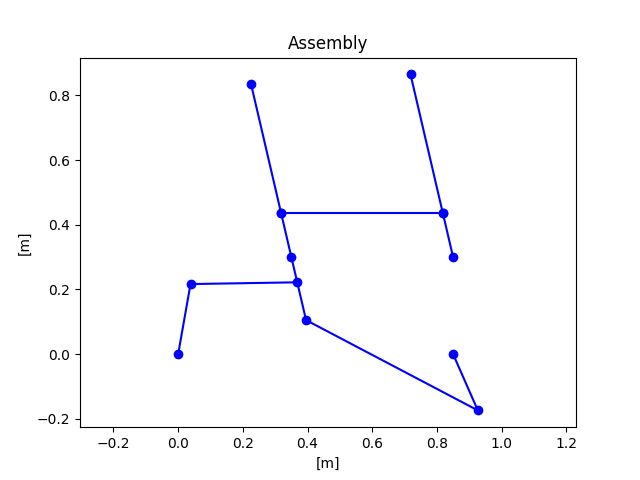

In [12]:
import numpy as np
import matplotlib.pyplot as plt


A = np.array([0, 0])
B = A+ rotate_vector(np.array([r1, 0]), theta1[0])
C = B + rotate_vector(np.array([r2, 0]), theta2)
D = A + np.array([rAD_x, rAD_y])
I = A + np.array([rAI_x, rAI_y])
H = A + np.array([rAH_x, rAH_y])
G = H + rotate_vector(np.array([r7, 0]), theta5)
F = G - rotate_vector(np.array([r6, 0]), theta4)
K = F + rotate_vector(np.array([r3, 0]), theta3)
E = F + rotate_vector(np.array([rED + rDF, 0]), theta3)
J = I + rotate_vector(np.array([rIJ, 0]), theta7)
L = I + rotate_vector(np.array([r5, 0]), theta7)



plt.figure()
pad1 = np.array([H, G, F, D, E, J, I])
plt.plot(pad1[:, 0], pad1[:, 1], '-bo')
pad2 = np.array([A, B,C])
plt.plot(pad2[:, 0], pad2[:, 1], '-bo')
pad3 = np.array([E,K])
plt.plot(pad3[:, 0], pad3[:, 1], '-bo')
pad4 = np.array([J,L])
plt.plot(pad4[:, 0], pad4[:, 1], '-bo')
plt.xlabel('[m]')
plt.ylabel('[m]')
plt.title('Assembly')
plt.axis('equal')
plt.show()


